# Exploratory data analysis, one variable at a time

**Master in Healthcare Analytics · Session: Introduction to EDA**
Dataset: Outpatient appointments, Riverbend Community Hospital (fictional), calendar year 2025.

Exploratory data analysis (EDA) is what you do *before* answering any question with data: you get to know each variable, check that it is what you think it is, and describe it in numbers, in pictures and in words. Done well, it prevents most of the mistakes that happen later.

This session teaches EDA as a **fixed procedure**: six steps that you apply to every variable, in the same order, every time. We apply it three times, to three different kinds of variable, so that you see which steps stay the same and which change:

| Variable | Kind | Where |
|---|---|---|
| `lead_time_days` | continuous (a measurement) | Part A |
| `prior_no_shows` | discrete count (0, 1, 2, ...) | Part B |
| `status` | categorical (named groups) | Part C |

Each variable is analysed **on its own**. Relationships between variables come in a later session.

### The six steps

1. **Understand the variable.** What does it measure, in what unit, and what does one value stand for? Read the data dictionary before touching the data.
2. **Check the data.** Is it stored as the right type? How many values are there? Any missing? Are the smallest and largest values plausible?
3. **Summarise with numbers.** Centre, spread, and range for a measurement; counts and percentages for categories.
4. **Draw it.** The right picture for the kind of variable.
5. **Look for oddities.** Outliers, pile-ups, caps, gaps, zeros: anything that would surprise a colleague who knows the process.
6. **Write it down.** Two or three plain sentences a clinical manager could read.

## Setup

Load the libraries and the data. `matplotlib` draws the pictures; a few style settings keep them consistent.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

appointments = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/appointments.csv", parse_dates=["booking_date", "appointment_date"])
print(appointments.shape)
appointments.head(3)

(79253, 18)


,appointment_id,patient_id,provider_id,clinic,visit_type,booking_date,appointment_date,appointment_time,weekday,slot_period,lead_time_days,prior_no_shows,sex,age,primary_payer,residence_type,distance_miles,status
0,A000001,P000240,DR023,Orthopedics,Established,2024-12-30,2025-01-02,08:00,Thursday,Early morning,3,4,M,46,Commercial,Suburban,9.6,Cancelled by clinic
1,A000002,P000663,DR023,Orthopedics,Annual wellness,2024-12-11,2025-01-02,08:00,Thursday,Early morning,22,0,F,40,Commercial,Urban,1.2,Arrived
2,A000003,P001386,DR024,Orthopedics,Telehealth,2024-12-20,2025-01-02,08:00,Thursday,Early morning,13,0,F,42,Commercial,Rural,6.5,Arrived


---
# Part A — A continuous variable: `lead_time_days`

## A1. Understand the variable

From the data dictionary: `lead_time_days` is the number of **days between the day an appointment was booked and the day of the appointment**, computed as `appointment_date − booking_date`. One value per appointment. Zero means the appointment was booked on the same day.

Why it matters: lead time is how long a patient waits for care after asking for it. Long lead times delay diagnosis and treatment, and appointments booked far ahead are more often forgotten. It is also one of the few things a clinic can change directly, by opening more slots or reserving some for short-notice booking.

Before looking at the data, write down what you *expect*. Most appointments within a few weeks; specialty clinics longer; nothing negative; probably a long right tail. Having an expectation is what lets you notice a surprise in step 5.

## A2. Check the data

Three quick checks: the data type, the count of values and missing values, and the range.

- `.dtype` tells us how pandas stores the column. Days should be a whole number (`int64`).
- `.isna().sum()` counts missing values.
- `.min()` and `.max()` give the range, to compare against what is plausible.

In [23]:
lead = appointments["lead_time_days"]

print("Data type:      ", lead.dtype)
print("Number of values:", len(lead))
print("Missing values: ", lead.isna().sum())
print("Minimum:        ", lead.min())
print("Maximum:        ", lead.max())

Data type:       int64
Number of values: 79253
Missing values:  0
Minimum:         0
Maximum:         120


Whole numbers, no missing values, nothing negative, and nothing absurd (120 days is four months, a long wait but a possible one). The data passes. On a real extract this is the step that catches negative lead times (a booking date entered after the appointment), values in the thousands (a default date such as 1900-01-01), and missing bookings.

One more check that is specific to this variable: the column should equal the difference between the two date columns. Trust, but verify.

In [24]:
recomputed = (appointments["appointment_date"] - appointments["booking_date"]).dt.days
print("lead_time_days matches the date difference on every row:", (recomputed == lead).all())

lead_time_days matches the date difference on every row: True


## A3. Summarise with numbers

For a measurement we want three things: the **centre**, the **spread**, and the **range**. `describe()` gives all of them at once:

- `mean` — the arithmetic average.
- `50%` — the **median**: half the values are below it.
- `std` — the standard deviation, a measure of spread around the mean.
- `25%` and `75%` — the first and third **quartiles**; between them lies the middle half of the data. Their difference is the **interquartile range (IQR)**.
- `min` and `max`.

In [25]:
lead.describe().round(1)

count    79253.0
mean        15.7
std         15.8
min          0.0
25%          6.0
50%         11.0
75%         19.0
max        120.0
Name: lead_time_days, dtype: float64

Reading this: the mean (15.7 days) is noticeably larger than the median (11 days). When mean and median disagree, it is because the distribution is **skewed**: a minority of long waits pulls the mean up. The median is the better "typical" value here. The middle half of appointments is booked between 6 and 19 days ahead (IQR = 13 days).

Two extra percentiles are worth adding for an operational variable, because managers ask about the tail, not the middle:

In [26]:
print("90th percentile:", lead.quantile(0.90), "days  (one appointment in ten is booked further ahead than this)")
print("95th percentile:", lead.quantile(0.95), "days")
print("Share booked within 7 days:", f"{(lead <= 7).mean():.1%}")
print("Share booked more than 30 days ahead:", f"{(lead > 30).mean():.1%}")

90th percentile: 33.0 days  (one appointment in ten is booked further ahead than this)
95th percentile: 46.0 days
Share booked within 7 days: 34.0%
Share booked more than 30 days ahead: 11.9%


## A4. Draw it

For a continuous variable, two pictures: a **histogram** (how many values fall in each band) and a **boxplot** (the five-number summary as a picture). They show the same data; the histogram shows the shape in detail, the boxplot compresses it into a form that is easy to compare across groups later.

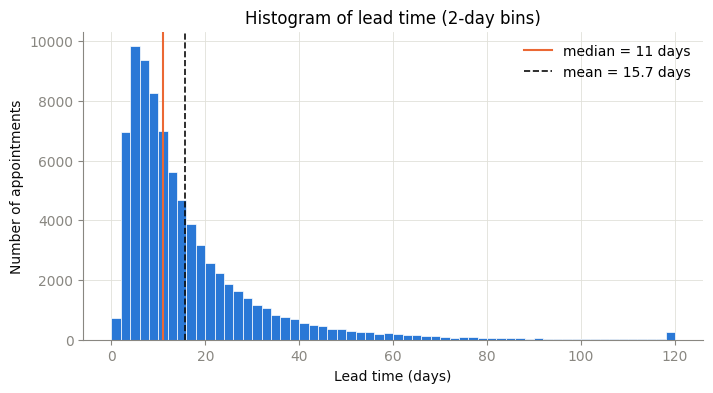

In [27]:
fig, ax = plt.subplots()
ax.hist(lead, bins=range(0, 122, 2), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(lead.median(), color=ORANGE, linewidth=1.5, label=f"median = {lead.median():.0f} days")
ax.axvline(lead.mean(), color=INK, linestyle="--", linewidth=1.2, label=f"mean = {lead.mean():.1f} days")
ax.set_xlabel("Lead time (days)"); ax.set_ylabel("Number of appointments")
ax.set_title("Histogram of lead time (2-day bins)")
ax.legend(frameon=False); plt.show()

**How to read a boxplot.** The box spans the first to the third quartile (the middle half of the data); the line inside it is the median. The "whiskers" extend from the box to the most extreme values that are still within 1.5 × IQR of the box. Anything beyond the whiskers is drawn as an individual point and is, by this convention, an **outlier**.

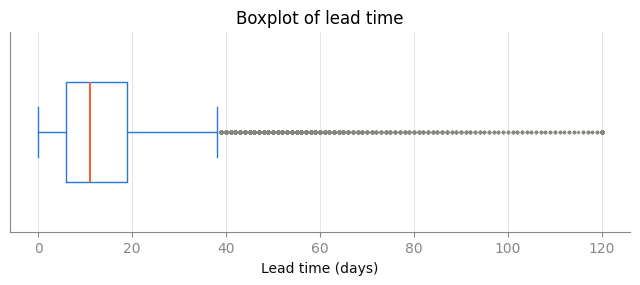

In [28]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.boxplot(lead, vert=False, widths=0.5, medianprops=dict(color=ORANGE, linewidth=1.5),
           boxprops=dict(color=BLUE), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
           flierprops=dict(marker=".", markersize=3, markerfacecolor=MUTED, markeredgecolor=MUTED, alpha=0.4))
ax.set_yticks([]); ax.set_xlabel("Lead time (days)"); ax.set_title("Boxplot of lead time")
plt.show()

The two pictures agree with the numbers: a peak around one week, a long tail to the right, and the median well to the left of the mean. The boxplot shows a dense cloud of "outliers" beyond about 40 days. That deserves a closer look in the next step.

## A5. Look for oddities

Three things in these pictures should make you pause.

**The outliers.** Let us count how many values the 1.5 × IQR rule flags.

In [29]:
q1, q3 = lead.quantile(0.25), lead.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_out = (lead > upper_fence).sum()
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}, upper fence = {upper_fence}")
print(f"Values above the fence: {n_out} ({n_out / len(lead):.1%} of appointments)")

Q1 = 6.0, Q3 = 19.0, IQR = 13.0, upper fence = 38.5
Values above the fence: 5830 (7.4% of appointments)


More than 7% of appointments are "outliers" by this rule. That is far too many to be errors. What is happening is that the 1.5 × IQR rule assumes a roughly symmetric distribution; applied to a skewed one it flags the whole tail. **These are not bad data; they are the long waits the clinic should be worried about.** The lesson: an outlier rule tells you where to look, not what to delete.

**The pile-up at 120.** The histogram shows a small spike at the far right edge.

In [30]:
print("Appointments with lead time exactly 120 days:", (lead == 120).sum())
print("Appointments with lead time between 100 and 119 days:", ((lead >= 100) & (lead < 120)).sum())

Appointments with lead time exactly 120 days: 231
Appointments with lead time between 100 and 119 days: 206


More appointments at exactly 120 than in the whole 100–119 range. A value that is more common than its neighbours at the edge of the range is the signature of a **cap**: the scheduling system does not allow bookings more than 120 days ahead, so everything that would have been longer is recorded as 120. You cannot see this in `describe()`; only the histogram shows it. In a real analysis you would confirm this with the scheduling team.

**Same-day bookings.** Zero is a legitimate value, but worth counting: same-day appointments behave differently from booked ones.

In [31]:
print("Same-day appointments (lead time = 0):", (lead == 0).sum(), f"({(lead == 0).mean():.2%})")

Same-day appointments (lead time = 0): 5 (0.01%)


## A6. Write it down

> Appointments at Riverbend's four outpatient clinics are booked a median of 11 days ahead; half fall between 6 and 19 days. The distribution is strongly right-skewed: one appointment in ten is booked more than 33 days ahead and one in twenty more than 45 days, so the mean (15.7 days) overstates the typical wait. The scheduling system caps bookings at 120 days, and the small cluster at that value represents patients whose true wait is unknown but at least four months. Long lead times are concentrated in the tail rather than being data errors.

Notice what the paragraph does: it gives the typical value, the spread, the shape, the tail in terms a manager cares about, and one data caveat. Nothing about standard deviations.

---
# Part B — A discrete count: `prior_no_shows`

## B1. Understand the variable

From the data dictionary: `prior_no_shows` is the **number of appointments the patient failed to attend without cancelling in the 365 days before this appointment**. One value per appointment; for the same patient it can go up over the year. It is a **count**: whole numbers, zero or more, with no upper limit in principle.

Why it matters: in nearly every study of missed appointments, a patient's recent history is the strongest single predictor of whether they will miss the next one. Clinics use it to decide who gets a reminder call.

Expectation: many zeros (most patients attend), a rapidly shrinking number of 1s, 2s, 3s, and a thin tail of patients who miss repeatedly.

## B2. Check the data

The same three checks. For a count, "plausible" means: whole numbers, none negative, and a maximum that makes sense given how many appointments a patient can have in a year.

In [32]:
prior = appointments["prior_no_shows"]

print("Data type:      ", prior.dtype)
print("Number of values:", len(prior))
print("Missing values: ", prior.isna().sum())
print("Minimum:        ", prior.min())
print("Maximum:        ", prior.max())

Data type:       int64
Number of values: 79253
Missing values:  0
Minimum:         0
Maximum:         38


Whole numbers, no missing values, none negative. A maximum of 38 missed appointments in a year is high but not impossible for a patient with weekly visits. We will look at that tail in step 5.

## B3. Summarise with numbers

Here the procedure changes. Because a count takes only a limited set of values, the most informative summary is a **frequency table**: how many appointments have 0 prior no-shows, how many have 1, and so on, with percentages. `value_counts()` builds it; `sort_index()` puts the values in numeric order.

In [33]:
freq = prior.value_counts().sort_index()
table = pd.DataFrame({"appointments": freq, "percent": (freq / freq.sum() * 100).round(1)})
table["cumulative_percent"] = table["percent"].cumsum().round(1)
table.head(10)

,appointments,percent,cumulative_percent
prior_no_shows,,,
0,38420,48.5,48.5
1,19453,24.5,73.0
2,9493,12.0,85.0
3,4317,5.4,90.4
4,2417,3.0,93.4
5,1390,1.8,95.2
6,822,1.0,96.2
7,563,0.7,96.9
8,429,0.5,97.4


Nearly half of appointments (48.5%) are for patients with no missed visit in the past year, and about 90% have two or fewer. The cumulative column answers "what share of appointments have *at most* k prior no-shows".

Because a count is a number, `describe()` still applies, and the mean and median still mean something. But be aware that for a variable like this the mean is dominated by the tail.

In [34]:
prior.describe().round(2)

count    79253.00
mean         1.37
std          2.72
min          0.00
25%          0.00
50%          1.00
75%          2.00
max         38.00
Name: prior_no_shows, dtype: float64

In [35]:
print("Most common value (mode):", prior.mode()[0])
print("Share with zero prior no-shows:", f"{(prior == 0).mean():.1%}")
print("Share with 5 or more:", f"{(prior >= 5).mean():.1%}")

Most common value (mode): 0
Share with zero prior no-shows: 48.5%
Share with 5 or more: 6.5%


## B4. Draw it

For a count, the picture is a **bar chart of the frequency table**, not a histogram. The difference matters: a histogram groups a continuous range into bins of our choosing; a bar chart has one bar per actual value, and the gaps between bars remind the reader that a patient cannot have 1.5 prior no-shows.

Values above 10 are rare, so we group them into a single "10+" bar to keep the chart readable.

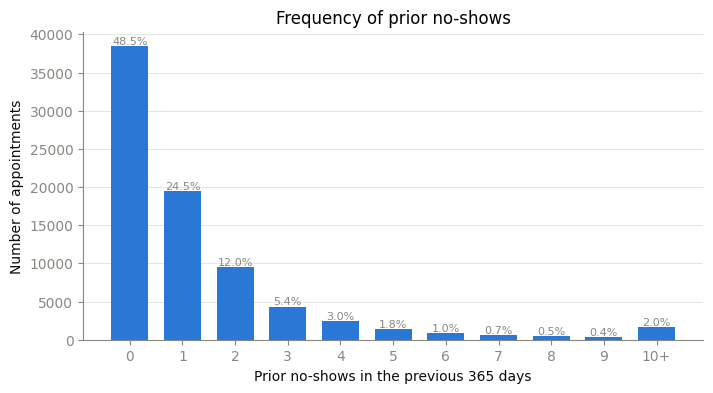

In [36]:
capped = prior.clip(upper=10)
counts = capped.value_counts().sort_index()
labels = [str(v) if v < 10 else "10+" for v in counts.index]

fig, ax = plt.subplots()
ax.bar(labels, counts.values, color=BLUE, width=0.7)
for x, v in zip(labels, counts.values):
    ax.text(x, v, f"{v / counts.sum():.1%}", ha="center", va="bottom", fontsize=8, color=MUTED)
ax.set_xlabel("Prior no-shows in the previous 365 days"); ax.set_ylabel("Number of appointments")
ax.set_title("Frequency of prior no-shows"); ax.grid(axis="x", visible=False)
plt.show()

The bar chart shows the expected shape: a tall bar at zero and bars that roughly halve with each step. A distribution that is mostly zeros with a long thin tail is common for counts of adverse events in healthcare (falls, readmissions, missed doses), and it is why the mean of such a count is rarely a good summary.

## B5. Look for oddities

**The tail.** Who are the patients with very high counts? Let us look at the appointments with 15 or more.

In [37]:
tail = appointments.loc[prior >= 15, ["patient_id", "appointment_date", "prior_no_shows", "status"]]
print("Appointments with 15+ prior no-shows:", len(tail), "belonging to", tail["patient_id"].nunique(), "patients")
tail.sort_values("prior_no_shows", ascending=False).head(8)

Appointments with 15+ prior no-shows: 751 belonging to 62 patients


,patient_id,appointment_date,prior_no_shows,status
78277,P002520,2025-12-26,38,No-show
75051,P002520,2025-12-10,38,Cancelled by patient
72695,P002520,2025-11-26,37,No-show
77029,P002520,2025-12-19,37,No-show
63443,P002520,2025-10-16,37,No-show
59959,P002520,2025-09-30,37,No-show
71330,P002520,2025-11-20,37,Cancelled by clinic
74475,P002520,2025-12-08,37,No-show


A small number of patients account for the entire extreme tail. This is typical and important: a handful of frequently-missing patients can distort any average, and they are also exactly the people a targeted intervention would reach. Note that these are real patterns, not data errors; nothing here needs "cleaning".

**The value changes within a patient.** Unlike age or sex, this variable is not fixed per patient. Looking at one patient's appointments in order shows the count rising after each no-show:

In [38]:
one_patient = tail["patient_id"].iloc[0]
appointments.loc[appointments["patient_id"] == one_patient, ["appointment_date", "prior_no_shows", "status"]].head(8)

,appointment_date,prior_no_shows,status
1146,2025-01-07,23,No-show
3468,2025-01-15,24,No-show
5650,2025-01-24,25,No-show
10178,2025-02-13,25,No-show
14309,2025-03-04,26,No-show
14630,2025-03-05,26,Cancelled by clinic
15467,2025-03-07,26,No-show
17415,2025-03-17,26,No-show


## B6. Write it down

> Just under half of appointments are for patients with no missed visit in the previous year, and nine in ten are for patients with two or fewer. The distribution is heavily concentrated at zero with a long thin tail: 6% of appointments belong to patients with five or more recent no-shows, and a few dozen patients account for all counts above fifteen. The average of 1.4 prior no-shows per appointment is not a useful figure; "most patients have none, a small group has many" is the honest description.

---
# Part C — A categorical variable: `status`

## C1. Understand the variable

From the data dictionary: `status` records **what happened to the appointment** and has four possible values: *Arrived*, *No-show*, *Cancelled by patient*, *Cancelled by clinic*. One value per appointment. It is **categorical**: the values are names, not numbers, and have no natural order.

Why it matters: this is the outcome the whole dataset was built around. Every later question ("which appointments are missed?") is a question about this column.

Expectation: most appointments attended; a no-show share somewhere in the 10–30% range typical of US ambulatory care; a smaller number of cancellations.

## C2. Check the data

For a categorical variable, the type check is different: pandas stores text as `str` (older versions show `object`), and the important question is **which distinct values appear**, and whether any of them is a typo or a variant of another ("No-show" vs "No show" vs "NS"). `unique()` lists them.

In [39]:
status = appointments["status"]

print("Data type:       ", status.dtype)
print("Number of values: ", len(status))
print("Missing values:  ", status.isna().sum())
print("Distinct values: ", list(status.unique()))

Data type:        object
Number of values:  79253
Missing values:   0
Distinct values:  ['Cancelled by clinic', 'Arrived', 'Cancelled by patient', 'No-show']


Exactly four values, spelled consistently, none missing. On a real extract this step routinely reveals five or six spellings of the same outcome, which must be harmonised before anything else.

## C3. Summarise with numbers

For a categorical variable the summary *is* the frequency table. There is no mean or median. We report counts and percentages, ordered from most to least common.

In [40]:
freq = status.value_counts()
pd.DataFrame({"appointments": freq, "percent": (freq / freq.sum() * 100).round(1)})

,appointments,percent
status,,
Arrived,61303,77.4
No-show,10738,13.5
Cancelled by patient,5590,7.1
Cancelled by clinic,1622,2.0


One derived number matters enough to compute separately. The **no-show rate** is conventionally defined as *No-show ÷ (Arrived + No-show)*: cancellations are excluded because a cancelled appointment never reached the day of the visit, so it could not have been a no-show. Including them in the denominator makes the problem look smaller than it is.

In [41]:
arrived, no_show = freq["Arrived"], freq["No-show"]
print(f"No-show share of all appointments:        {no_show / freq.sum():.1%}")
print(f"No-show rate (excluding cancellations):   {no_show / (arrived + no_show):.1%}")

No-show share of all appointments:        13.5%
No-show rate (excluding cancellations):   14.9%


## C4. Draw it

A **bar chart** again, one bar per category. For categories with no natural order, sort the bars by frequency so the eye reads the ranking. Percentages on the bars save the reader arithmetic.

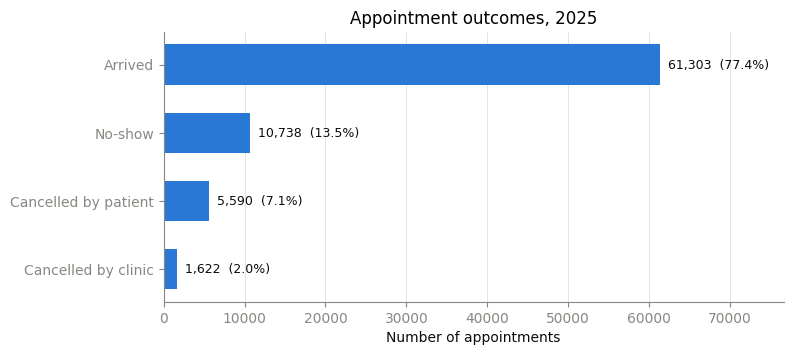

In [42]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(freq.index[::-1], freq.values[::-1], color=BLUE, height=0.6)
for y, v in zip(freq.index[::-1], freq.values[::-1]):
    ax.text(v, y, f"  {v:,}  ({v / freq.sum():.1%})", va="center", fontsize=9, color=INK)
ax.set_xlabel("Number of appointments"); ax.set_title("Appointment outcomes, 2025")
ax.grid(axis="y", visible=False); ax.set_xlim(0, freq.max() * 1.25)
plt.show()

A pie chart is the other common choice for a categorical variable. It is fine for two or three categories of very different size; with four or more, or with categories of similar size, a bar chart is easier to read accurately.

## C5. Look for oddities

For a categorical variable the oddities are usually about the categories themselves rather than the values:

- **Rare categories.** *Cancelled by clinic* is only 2% of appointments. Rare categories are not a problem in themselves, but any later comparison involving them will rest on few observations.
- **Categories that hide a mixture.** *Cancelled by patient* combines a patient who cancelled three weeks ahead (slot easily refilled) with one who cancelled that morning (slot lost, almost a no-show). The data does not say when the cancellation happened, so this category is less informative than it looks. Knowing what a category *cannot* tell you is part of EDA.
- **Consistency with other columns.** A quick logic check: appointments cannot have both a status and, say, an arrival time in the future. This dataset has no arrival time column, so there is nothing to cross-check; on a richer extract there would be.

## C6. Write it down

> Of 79,253 appointments scheduled in 2025, 77% were attended, 13.5% were no-shows, 7% were cancelled by the patient and 2% by the clinic. Excluding cancellations, the no-show rate was 14.9%, in the middle of the range reported for US ambulatory clinics. Patient cancellations are recorded without a cancellation date, so the share of late cancellations that effectively behaved as no-shows is unknown.

---
# What stayed the same, what changed

| Step | Continuous (`lead_time_days`) | Count (`prior_no_shows`) | Categorical (`status`) |
|---|---|---|---|
| 1. Understand | definition, unit, what one value is | same | same |
| 2. Check | type, n, missing, min/max plausible | same | type, n, missing, **distinct values and spellings** |
| 3. Summarise | mean, median, SD, quartiles, percentiles | **frequency table** (+ mean/median with care) | frequency table only |
| 4. Draw | histogram + boxplot | **bar chart** of the frequency table | bar chart, sorted by frequency |
| 5. Oddities | outliers (with judgement), caps, zeros | zero share, extreme tail, changes within patient | rare categories, categories hiding a mixture |
| 6. Write | typical value, spread, tail, caveat | same | shares, derived rate, caveat |

Steps 1, 2 and 6 are identical in spirit for every variable. Steps 3 to 5 depend on the kind of variable, and the first decision in any EDA is therefore: *is this a measurement, a count, or a category?*

Two habits to carry forward. First, **write your expectation before you look**; surprises are only visible against an expectation. Second, **an unusual value is a question, not an error**: the long lead times, the cap at 120 and the patient with 38 missed visits are all real, and each one taught us something about how the clinic works.